# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Enter Group Number]

**Student names & numbers:**
* [Name 1] - [Student no.]
* [Name 2] - [Student no.]
* [Name 3] - [Student no.]


---

## 0. Setup

**Import libraries**

In [188]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [189]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")

df_weather = pd.read_csv("./data/weather.csv", comment='#')

In [190]:
df_weather[["FG", "TG", "TN", "TX", "RH"]] = df_weather[["FG", "TG", "TN", "TX", "RH"]] / 10
df_weather["date"] = pd.to_datetime(df_weather["YYYYMMDD"], format="%Y%m%d")
df_weather = df_weather.rename(columns={
    "FG": "wind_speed",
    "TG": "temp_mean",
    "TN": "temp_min",
    "TX": "temp_max",
    "RH": "precipitation"
})
df_weather.head()

,STN,YYYYMMDD,wind_speed,temp_mean,temp_min,temp_max,precipitation,date
0,310,20100101,5.6000,0.6000,-1.5000,1.9000,0.0000,2010-01-01
1,310,20100102,5.8000,1.2000,-0.4000,2.2000,4.7000,2010-01-02
2,310,20100103,3.5000,-1.5000,-2.9000,2.1000,1.5000,2010-01-03
3,310,20100104,5.8000,-0.4000,-3.4000,3.7000,0.2000,2010-01-04
4,310,20100105,5.8000,0.5000,-1.4000,2.9000,0.0000,2010-01-05


In [191]:
df_observation.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax
0,50.7500,5.6500,2010-01-01,0.0000,0,0
1,50.7500,5.6500,2010-01-02,26.0000,0,0
2,50.7500,5.6500,2010-01-03,3.0000,0,0
3,50.7500,5.6500,2010-01-04,0.0000,0,0
4,50.7500,5.6500,2010-01-05,0.0000,0,0


In [192]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       object 
dtypes: float64(3), int64(1), object(2)
memory usage: 574.9+ MB


In [193]:
df_observation.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,12558786.0000,12558786.0000,12558785.0000,12558786.0000
mean,52.2299,5.5329,8.1428,0.0897
std,0.6647,0.8780,62.6530,2.5155
min,3.5000,3.3500,0.0000,0.0000
25%,51.7000,4.9000,0.0000,0.0000
50%,52.2000,5.6500,1.0000,0.0000
75%,52.8000,6.2000,6.0000,0.0000
max,53.5000,53.4000,100040.0000,1011.0000


In [194]:
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)


df_obs_habitat_weather = df_obs_habitat.merge(
    df_weather,
    left_on='eventDate',
    right_on='date',
    how='left'
)

df_obs_habitat_weather = df_obs_habitat_weather.drop(columns=['STN', 'YYYYMMDD', 'date'])
df_obs_habitat_weather.head()


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,wind_speed,temp_mean,temp_min,temp_max,precipitation
0,50.7500,5.6500,2010-01-01,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.6000,0.6000,-1.5000,1.9000,0.0000
1,50.7500,5.6500,2010-01-02,26.0000,0,0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.8000,1.2000,-0.4000,2.2000,4.7000
2,50.7500,5.6500,2010-01-03,3.0000,0,0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,3.5000,-1.5000,-2.9000,2.1000,1.5000
3,50.7500,5.6500,2010-01-04,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.8000,-0.4000,-3.4000,3.7000,0.2000
4,50.7500,5.6500,2010-01-05,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.8000,0.5000,-1.4000,2.9000,0.0000


In [195]:
# CODE CELL: Missing values in the merged dataset
df_missing = df_obs_habitat_weather[df_obs_habitat_weather.isnull().any(axis=1)]
display(df_missing) 

df_clean = df_obs_habitat_weather.dropna(subset=['agricultural'], how='all')
display(df_clean.isnull().sum().to_frame(name='missing_count'))


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,wind_speed,temp_mean,temp_min,temp_max,precipitation
12558756,3.5500,53.4000,2026-01-01,50.0000,1011,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558757,3.6500,53.4000,2026-01-02,20.0000,1011,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558758,3.7500,53.4000,2026-01-03,100.0000,1011,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558759,3.5000,53.3000,2026-01-04,20.0000,1011,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558760,3.5000,53.2000,2026-01-05,80.0000,1011,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558761,3.5000,53.1000,2026-01-06,90.0000,1011,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558762,3.6000,53.1000,2026-01-07,20.0000,1011,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558763,3.7000,53.1000,2026-01-08,20.0000,1011,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558764,3.8000,53.1000,2026-01-09,20.0000,1011,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558765,3.5000,53.0000,2026-01-10,20.0000,1011,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count
decimalLatitude,0
decimalLongitude,0
eventDate,0
total_observations,0
speciesgroup_observations,0
Dicentrarchus labrax,0
agricultural,0
built,0
coast,0
forest,0


In [196]:
df_clean.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,sand/heather,water,wetland,wind_speed,temp_mean,temp_min,temp_max,precipitation
count,12558756.0000,12558756.0000,12558756,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000,12558756.0000
mean,52.2301,5.5328,2017-12-31 11:59:59.999999744,8.1188,0.0873,9.4523,2.4048,1.3029,1.6212,1.5015,0.1882,1.2455,0.2250,6.1474,11.6690,9.1040,14.5138,2.0985
min,50.7500,3.3500,2010-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.5000,-6.6000,-10.7000,-4.6000,-0.1000
25%,51.7000,4.9000,2013-12-31 18:00:00,0.0000,0.0000,5.3484,0.7667,0.0000,0.1494,0.7249,0.0000,0.0990,0.0000,4.1000,7.3000,5.1000,9.5000,0.0000
50%,52.2000,5.6500,2017-12-31 12:00:00,1.0000,0.0000,10.5682,1.5599,0.0000,0.7092,1.1998,0.0000,0.3102,0.0182,5.6000,11.5000,9.0000,14.4000,0.0000
75%,52.8000,6.2000,2021-12-31 06:00:00,6.0000,0.0000,13.8008,3.2916,0.0000,2.0364,2.0065,0.0234,1.0330,0.1417,7.7000,16.5000,13.7000,19.5000,2.2000
max,53.5000,7.2000,2025-12-31 00:00:00,100040.0000,753.0000,18.1046,14.3538,19.3487,16.9985,10.3983,10.3443,18.9087,14.2241,18.0000,27.9000,22.2000,37.3000,78.0000
std,0.6605,0.8749,NaN,39.2055,1.9714,5.1479,2.4198,3.9702,2.3857,1.1679,0.7710,2.6882,0.7064,2.6995,5.7455,5.3693,6.5363,4.4958


In [197]:
# --- STEP 2.4: DATA CONSTRUCTION ---

# Convert the species column to numeric so we can do calculations on it
df_clean = df_clean.copy()  # fixes the SettingWithCopyWarning
df_clean['Dicentrarchus labrax'] = pd.to_numeric(df_clean['Dicentrarchus labrax'], errors='coerce')

# Define the target variable: 1 if present, 0 if absent
df_clean['target'] = (df_clean['Dicentrarchus labrax'] > 0).astype(int)

# Check the target distribution to understand class imbalance
print("Target Distribution:")
print(df_clean['target'].value_counts(normalize=True))

# Apply One-Hot Encoding to 'main_habitat'
df_final = pd.get_dummies(df_clean, columns=['main_habitat'], prefix='main_hab')

# Confirm the new columns created by OHE
print("\nNew columns after One-Hot Encoding:")
print([col for col in df_final.columns if 'main_hab' in col])

# Show the first few rows to verify
df_final.head()

Target Distribution:
target
0   0.9998
1   0.0002
Name: proportion, dtype: float64

New columns after One-Hot Encoding:
['main_hab_agricultural', 'main_hab_built', 'main_hab_coast', 'main_hab_forest', 'main_hab_other', 'main_hab_sand/heather', 'main_hab_water', 'main_hab_wetland']


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,...,precipitation,target,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
0,50.7500,5.6500,2010-01-01,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,...,0.0000,0,True,False,False,False,False,False,False,False
1,50.7500,5.6500,2010-01-02,26.0000,0,0,1.7747,0.0568,0.0000,0.0616,...,4.7000,0,True,False,False,False,False,False,False,False
2,50.7500,5.6500,2010-01-03,3.0000,0,0,1.7747,0.0568,0.0000,0.0616,...,1.5000,0,True,False,False,False,False,False,False,False
3,50.7500,5.6500,2010-01-04,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,...,0.2000,0,True,False,False,False,False,False,False,False
4,50.7500,5.6500,2010-01-05,0.0000,0,0,1.7747,0.0568,0.0000,0.0616,...,0.0000,0,True,False,False,False,False,False,False,False


In [198]:
# --- STEP 2.5: DATA FORMAT CONVERSION ---

# Define the feature columns: 8 habitat percentages + 8 OHE habitat indicators = 16 features
habitat_percentages = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']
encoded_habitats = [col for col in df_final.columns if 'main_hab' in col]

all_features = habitat_percentages + encoded_habitats

# Create the feature matrix X and target vector y
X = df_final[all_features]
y = df_final['target']

# Convert to NumPy arrays for Scikit-learn
X_array = X.values
y_array = y.values

# Verify the shapes and show a sample
print("DataFrame Representation (X head - showing all 16 features):")
display(X.head())

print(f"\nNumPy Array Representation:")
print(f"X array shape: {X_array.shape}")
print(f"y array shape: {y_array.shape}")
print(f"X array sample (first row):\n{X_array[0]}")

DataFrame Representation (X head - showing all 16 features):


,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
0,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,True,False,False,False,False,False,False,False
1,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,True,False,False,False,False,False,False,False
2,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,True,False,False,False,False,False,False,False
3,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,True,False,False,False,False,False,False,False
4,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,True,False,False,False,False,False,False,False



NumPy Array Representation:
X array shape: (12558756, 16)
y array shape: (12558756,)
X array sample (first row):
[1.7747000000000002 0.0568 0.0 0.0616 0.0582 0.0 0.4688 0.0 True False
 False False False False False False]


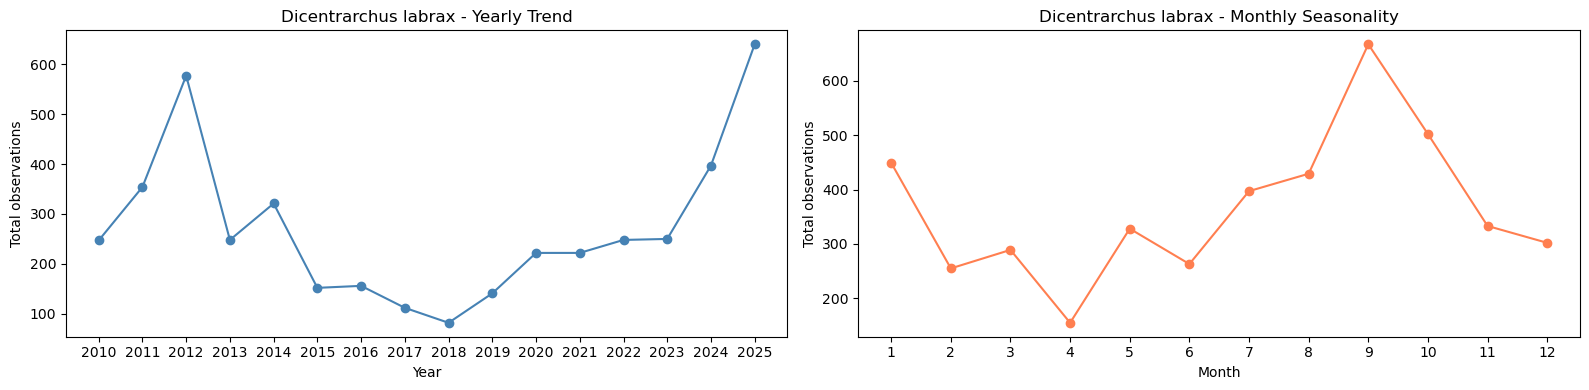

In [199]:
df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'])
df_clean['year'] = df_clean['eventDate'].dt.year
df_clean['month'] = df_clean['eventDate'].dt.month

# ===== Year trend =====
yearly_species = (
    df_clean.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# ===== Month seasonality =====
monthly_species = (
    df_clean.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- left: yearly ---
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# --- right: monthly ---
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

**Business objective(s)**

*Justify why a data-driven baseline is needed*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [200]:
# CODE CELL: Show basic statistics and information

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

In [201]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [202]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [203]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [204]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [205]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |